In [1]:
import jax
from jax import flatten_util, vmap 
import jax.numpy as jnp
import jax.random as jr
import os
import matplotlib.pyplot as plt
from physical_diffusion_fns.helper_fns import sample_gaussian_mixture, normalize_samples, sample_forward_process, get_best_params, smooth_parameters, interpolate_parameters
from physical_diffusion_fns.learning_fns import setup_MLE_loss_per_batch, setup_MLE_gradient_per_batch, CD1_gradient, setup_score_matching_loss_per_batch, run_optimization
from physical_diffusion_fns.plotting_fns import plot_energy_and_distributions, plot_parameter_evolution, plot_forward_marginals, visualize_connectivity
from physical_diffusion_fns.network_fns import setup_duffing_network_energy_fn, setup_overdamped_SDE, solve_SDE  

jax.config.update("jax_enable_x64", True)

CUDA backend failed to initialize: Unable to use CUDA because of the following issues with CUDA components:
Outdated cuDNN installation found.
Version JAX was built against: 8907
Minimum supported: 9100
Installed version: 8907
The local installation version must be no lower than 9100..(Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


# Setup Problem

### Generate samples from a Gaussian mixture - the target distribution

In [2]:
# Set random seed
key = jr.PRNGKey(0)

# Parameters
N = 2  # number of dimensions
N_mixgauss = 3  # number of mixture components
n_samples = 10000

# Define mixture weights (must sum to 1)
weights = jnp.array([.5, .5])

# Define means
means = jnp.array([
    [1., 1.],   # mean of first Gaussian
    [-1., -1.],  # mean of second Gaussian
])

# Define covariance matrices
covs = jnp.array([
    [[0.001, 0.0],    # covariance of first Gaussian
        [0.0, 0.001]],
    [[0.001, 0.0],   # covariance of second Gaussian
        [0.0, 0.001]],
])
# Generate samples
samples_0 = sample_gaussian_mixture(key, n_samples, weights, means, covs)
# Normalize samples
# samples = normalize_samples(samples_raw)



### Plot samples and marginal of target distributions

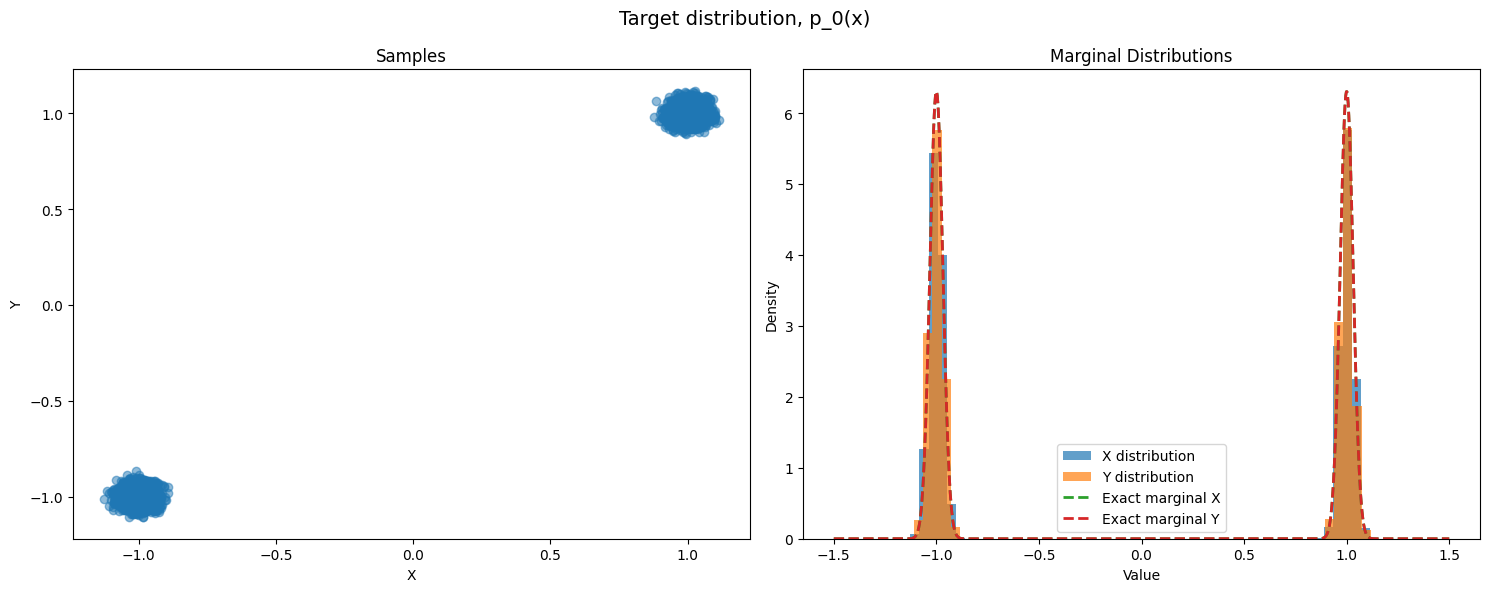

In [3]:
# Plot samples and marginal distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Target distribution, p_0(x)', fontsize=14)

# First subplot: Scatter plot of samples
ax1.scatter(samples_0[:, 0], samples_0[:, 1], alpha=0.5)
ax1.set_title('Samples')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')

# Second subplot: Combined marginal distributions
ax2.hist(samples_0[:, 0], bins=50, density=True, alpha=0.7, label='X distribution')
ax2.hist(samples_0[:, 1], bins=50, density=True, alpha=0.7, label='Y distribution')

# Add exact marginal Gaussians
x = jnp.linspace(-1.5, 1.5, 1000)
for dim in range(2):
    marginal = jnp.zeros_like(x)
    for w, m, c in zip(weights, means, covs):
        mean = m[dim]
        std = jnp.sqrt(c[dim, dim])
        marginal += w * jnp.exp(-0.5 * ((x - mean) / std) ** 2) / (std * jnp.sqrt(2 * jnp.pi))
    ax2.plot(x, marginal, '--', linewidth=2, label=f'Exact marginal {["X", "Y"][dim]}')

ax2.set_title('Marginal Distributions')
ax2.set_xlabel('Value')
ax2.set_ylabel('Density')
ax2.legend()

plt.tight_layout()
plt.show()

### Network size and topology

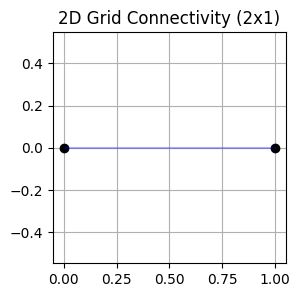

In [4]:
N_osc = 2
connectivity = jnp.array([[0, 1]])
visualize_connectivity(connectivity,grid_size_x=2,grid_size_y=1)

### Setup initial params 

In [5]:
k_lin_0 = jnp.array([-1., -1.])
k_duff_0 = jnp.array([1., 0.])
c_lin_0 = jnp.array([0.,])
c_optomech_0 = jnp.array([0.,])

params_initial = (k_lin_0, k_duff_0, c_lin_0, c_optomech_0)
params_names = ["k_lin", "k_duff", "c_lin", "c_optomech"]
params_flattened_initial, unflatten = flatten_util.ravel_pytree(params_initial)

# some initial guess from skewed distribution


params_flattened_initial = jnp.array([-614.42648671,  588.10603632,  482.38294911, 1459.22532574,
         81.11413943,    0.        ])



### Build energy

In [6]:
energy_fn = setup_duffing_network_energy_fn(connectivity, unflatten)

### Plot initial energy landscape

Initial Parameters probability distribution total (should be ≈ 1): 1.000000


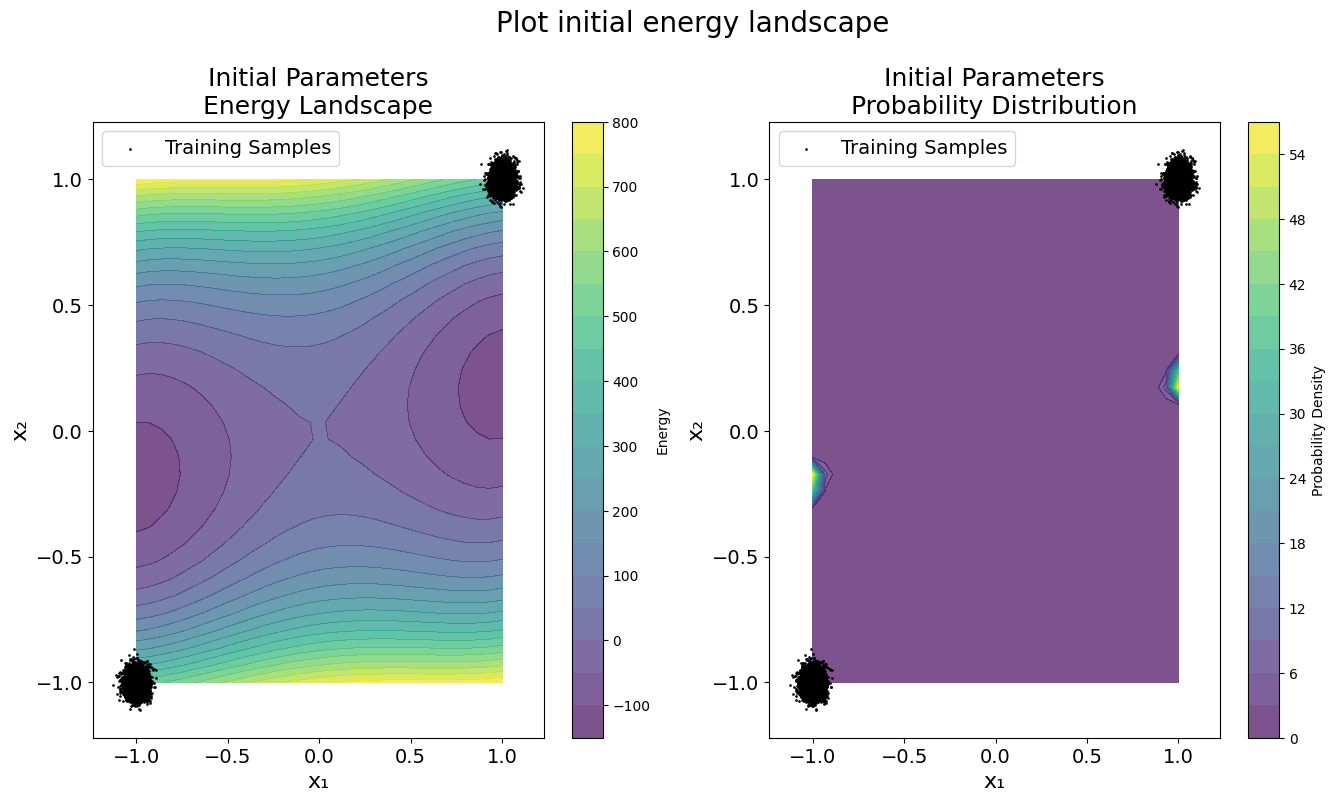

In [7]:
# Example usage:
param_list = [params_flattened_initial]
titles = ["Initial Parameters"]

plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=samples_0,
    x1_range=(-1, 1),   
    x2_range=(-1, 1),   
    n_points=30,       
    titles=titles,      
    figsize=(16, 8),   
    fontsize=16,        
    sample_stride=1,
    suptitle="Plot initial energy landscape" 
)

# Learning

In [8]:
# Choose training method
training_method = "SM"  # Options: "SM" (Score Matching), "CD1" (Contrastive Divergence), "MLE" (Maximum Likelihood)

# Setup loss and gradient functions based on selected method
if training_method == "SM":
    loss_fn_per_batch = setup_score_matching_loss_per_batch(energy_fn)
    gradient_fn_per_batch = None
    maximize = False
elif training_method == "CD1":
    loss_fn_per_batch = setup_score_matching_loss_per_batch(energy_fn)
    gradient_fn_per_batch = lambda flattened_args, batch: -CD1_gradient(energy_fn, batch, flattened_args, dt=0.001, D=1, key=key, num_noise_samples=1000)
    maximize = False
elif training_method == "MLE":
    loss_fn_per_batch = setup_MLE_loss_per_batch(energy_fn)
    gradient_fn_per_batch = setup_MLE_gradient_per_batch(energy_fn)
    maximize = True
else:
    raise ValueError(f"Unknown training method: {training_method}. Choose from 'SM', 'CD1', or 'MLE'.")

#### Optimization parameters and filenames

In [9]:
# Forward process parameters
n_time_steps = 300
t_forward = 1.0
sigma_forward = .5
forward_time_pts = jnp.exp(jnp.linspace(jnp.log(1e-20), jnp.log(t_forward), n_time_steps))
forward_time_pts = forward_time_pts.at[0].set(0.)

# Optimization parameters
learning_rate = 1.
n_epochs = 100000//2
batch_size = 2*128
window_size=1000
tolerance=1e-16
patience=50


In [10]:
comment = ""
optimization_folder = (f"{training_method}_"
           f"t_forward_{t_forward}_"
           f"n_timesteps_{n_time_steps}_"
           f"lr_{learning_rate}_"
           f"epochs_{n_epochs}_"
           f"batch_{batch_size}_"
           f"window_{window_size}_"
           f"tol_{tolerance}_"
           f"patience_{patience}_"
           f"{comment}")

In [11]:
# Setup output directories
base_dir = "out/problems"
problem_type_folder = "mixture_gaussians_sampling"
problem_folder = f"weights_{weights}_means_{means.flatten()}"  # Replace with your actual parameters

output_dir = os.path.join(base_dir, problem_type_folder, problem_folder,optimization_folder)

# Create directories if they don't exist
os.makedirs(output_dir, exist_ok=True)

### Print final distribution of the forward

Saving figure to out/problems/mixture_gaussians_sampling/weights_[0.5 0.5]_means_[ 1.  1. -1. -1.]/SM_t_forward_1.0_n_timesteps_300_lr_1.0_epochs_50000_batch_256_window_1000_tol_1e-16_patience_50_


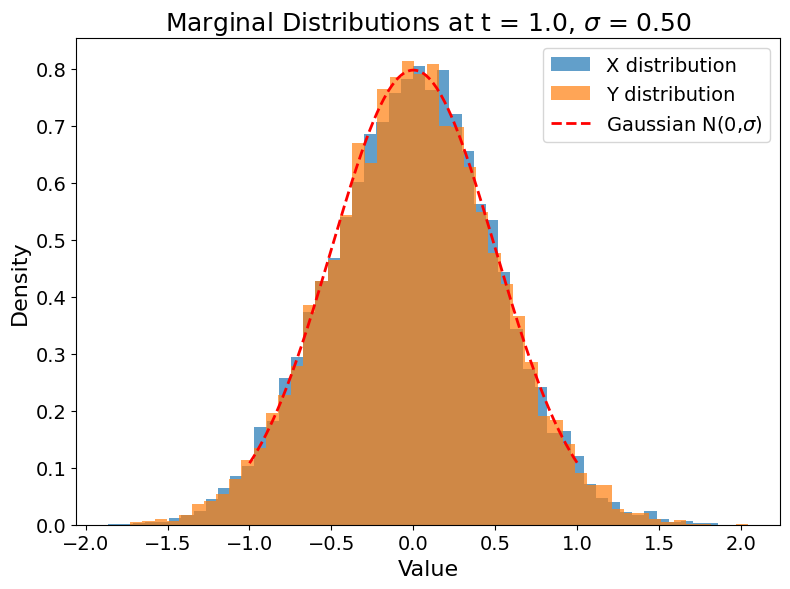

In [12]:
key, subkey = jr.split(key)
samples_t = sample_forward_process(t_forward, n_samples, D=1, sigma_final=sigma_forward, samples0=samples_0, key=subkey)
plot_forward_marginals(samples_t, t_forward, sigma_forward, beta=1.0, path=output_dir, save_fig=True, fontsize=16)

Optimization for time 0.0
Epoch 0 - Loss: 2132615.7446
Epoch 100 - Loss: 1751490.5446
Epoch 200 - Loss: 1404489.8249
Epoch 300 - Loss: 1115172.3765
Epoch 400 - Loss: 885775.2193
Epoch 500 - Loss: 697288.3478
Epoch 600 - Loss: 520621.9776
Epoch 700 - Loss: 395166.3290
Epoch 800 - Loss: 292187.3221
Epoch 900 - Loss: 208947.7400
Epoch 1000 - Loss: 151833.9545
Epoch 1100 - Loss: 107916.3807
Epoch 1200 - Loss: 71885.9032
Epoch 1300 - Loss: 46680.8757
Epoch 1400 - Loss: 30573.0021
Epoch 1500 - Loss: 18971.0610
Epoch 1600 - Loss: 10982.5761
Epoch 1700 - Loss: 5747.7695
Epoch 1800 - Loss: 2877.2817
Epoch 1900 - Loss: 1543.9252
Epoch 2000 - Loss: 81.0170
Epoch 2100 - Loss: -167.2478
Epoch 2200 - Loss: -831.3999
Epoch 2300 - Loss: -877.5117
Epoch 2400 - Loss: -869.3187
Epoch 2500 - Loss: -894.7523
Epoch 2600 - Loss: -891.2966
Epoch 2700 - Loss: -1071.2301
Epoch 2800 - Loss: -996.8668
Epoch 2900 - Loss: -979.1320
Epoch 3000 - Loss: -1008.7614
Epoch 3100 - Loss: -1025.1160
Epoch 3200 - Loss: -1023

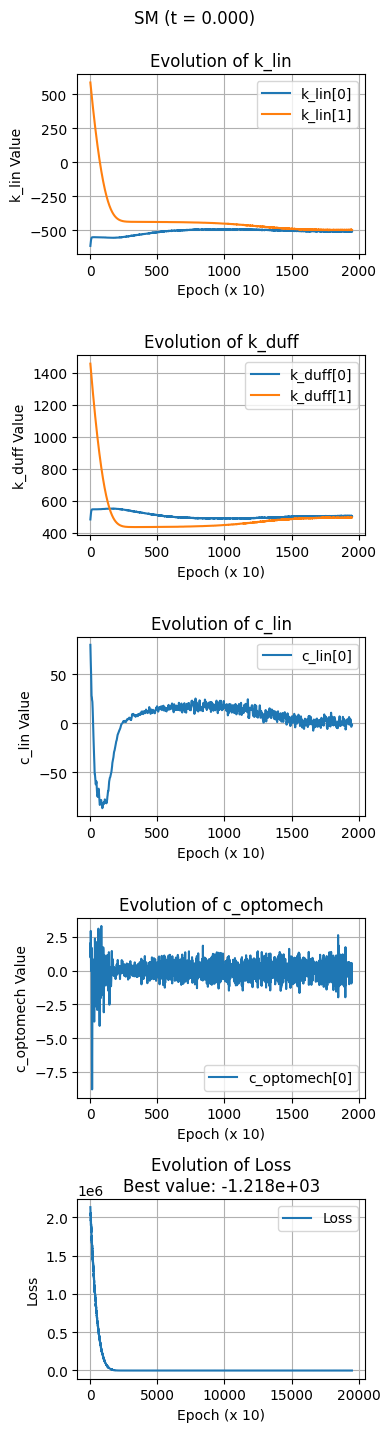

Optimization for time 1.1665131316981968e-20
Epoch 0 - Loss: -982.3983
Epoch 100 - Loss: -1025.7021
Epoch 200 - Loss: -1101.8173
Epoch 300 - Loss: -975.6136
Epoch 400 - Loss: -887.0142
Epoch 500 - Loss: -923.7260
Epoch 600 - Loss: -954.1179
Epoch 700 - Loss: -1034.7158
Epoch 800 - Loss: -1023.6786
Epoch 900 - Loss: -1185.0251
Epoch 1000 - Loss: -944.3986
Epoch 1100 - Loss: -992.2346
Epoch 1200 - Loss: -1021.8607
Epoch 1300 - Loss: -908.3671
Epoch 1400 - Loss: -1073.2728
Epoch 1500 - Loss: -977.0859
Epoch 1600 - Loss: -937.5285
Epoch 1700 - Loss: -1002.3551
Epoch 1800 - Loss: -906.1352
Epoch 1900 - Loss: -1059.8952
Epoch 2000 - Loss: -837.3647
Epoch 2100 - Loss: -1074.0668
Epoch 2200 - Loss: -947.8632
Epoch 2300 - Loss: -902.3996
Epoch 2400 - Loss: -1021.7164
Epoch 2500 - Loss: -1075.3132
Epoch 2600 - Loss: -901.5655
Epoch 2700 - Loss: -1119.3166
Epoch 2800 - Loss: -887.2242
Epoch 2900 - Loss: -872.0608
Epoch 3000 - Loss: -915.9735
Epoch 3100 - Loss: -978.3563
Epoch 3200 - Loss: -1001.2

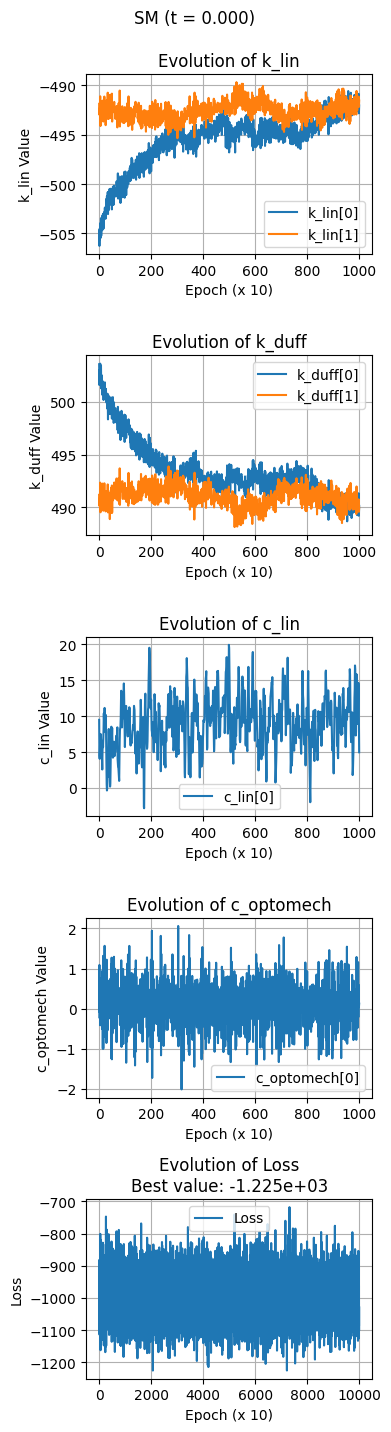

Optimization for time 5.442343548300262e-20
Epoch 0 - Loss: -962.8536
Epoch 100 - Loss: -1029.3165
Epoch 200 - Loss: -1180.9999
Epoch 300 - Loss: -1022.0897
Epoch 400 - Loss: -1049.8762
Epoch 500 - Loss: -1068.9475
Epoch 600 - Loss: -887.0024
Epoch 700 - Loss: -1022.0270
Epoch 800 - Loss: -1079.0938
Epoch 900 - Loss: -1041.5516
Epoch 1000 - Loss: -1041.0006
Epoch 1100 - Loss: -900.5794
Epoch 1200 - Loss: -971.5716
Epoch 1300 - Loss: -1008.9000
Epoch 1400 - Loss: -1003.8056
Epoch 1500 - Loss: -1017.9576
Epoch 1600 - Loss: -1048.5455
Epoch 1700 - Loss: -1099.4651
Epoch 1800 - Loss: -998.5931
Epoch 1900 - Loss: -1015.8947
Epoch 2000 - Loss: -905.9556
Epoch 2100 - Loss: -1031.6160
Epoch 2200 - Loss: -1078.1382
Epoch 2300 - Loss: -944.9745
Epoch 2400 - Loss: -990.9395
Epoch 2500 - Loss: -1033.1169
Epoch 2600 - Loss: -1072.2991
Epoch 2700 - Loss: -1079.9877
Epoch 2800 - Loss: -1019.4333
Epoch 2900 - Loss: -961.0766
Epoch 3000 - Loss: -960.4613
Epoch 3100 - Loss: -982.4916
Epoch 3200 - Loss: 

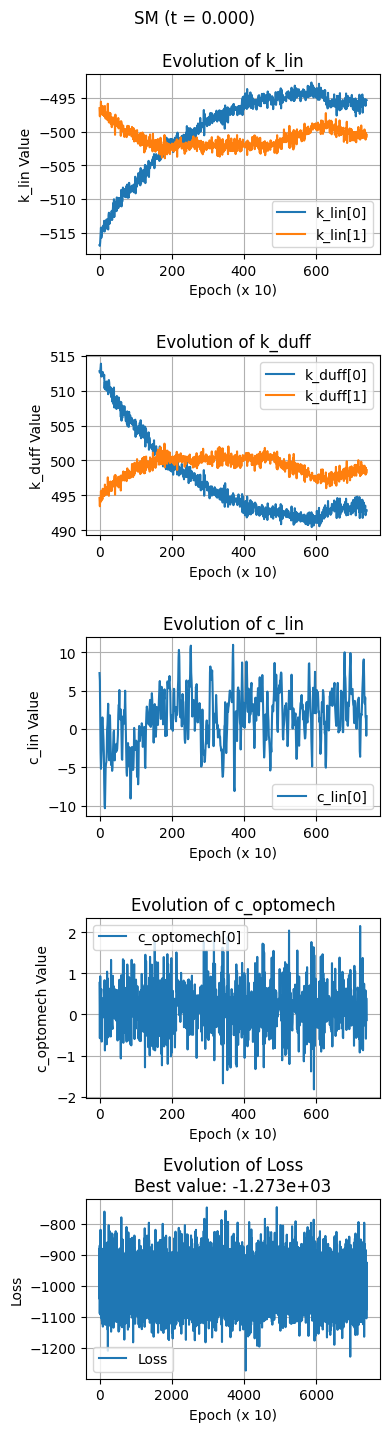

Optimization for time 2.539114433680342e-19
Epoch 0 - Loss: -870.3623
Epoch 100 - Loss: -985.7837
Epoch 200 - Loss: -926.6354
Epoch 300 - Loss: -959.1118
Epoch 400 - Loss: -1010.9070
Epoch 500 - Loss: -1050.4313
Epoch 600 - Loss: -973.5822
Epoch 700 - Loss: -1083.5345
Epoch 800 - Loss: -991.3607
Epoch 900 - Loss: -954.7015
Epoch 1000 - Loss: -1057.0199
Epoch 1100 - Loss: -901.8732
Epoch 1200 - Loss: -996.9961
Epoch 1300 - Loss: -922.3632
Epoch 1400 - Loss: -1087.7150
Epoch 1500 - Loss: -1044.1182
Epoch 1600 - Loss: -1074.0277
Epoch 1700 - Loss: -879.9332
Epoch 1800 - Loss: -1016.0635
Epoch 1900 - Loss: -1080.9903
Epoch 2000 - Loss: -951.2707
Epoch 2100 - Loss: -1014.5761
Epoch 2200 - Loss: -962.8131
Epoch 2300 - Loss: -989.8044
Epoch 2400 - Loss: -1014.7891
Epoch 2500 - Loss: -1004.8439
Epoch 2600 - Loss: -1016.1608
Epoch 2700 - Loss: -1050.4910
Epoch 2800 - Loss: -991.8939
Epoch 2900 - Loss: -991.4304
Epoch 3000 - Loss: -958.8946
Epoch 3100 - Loss: -991.7687
Epoch 3200 - Loss: -1035.0

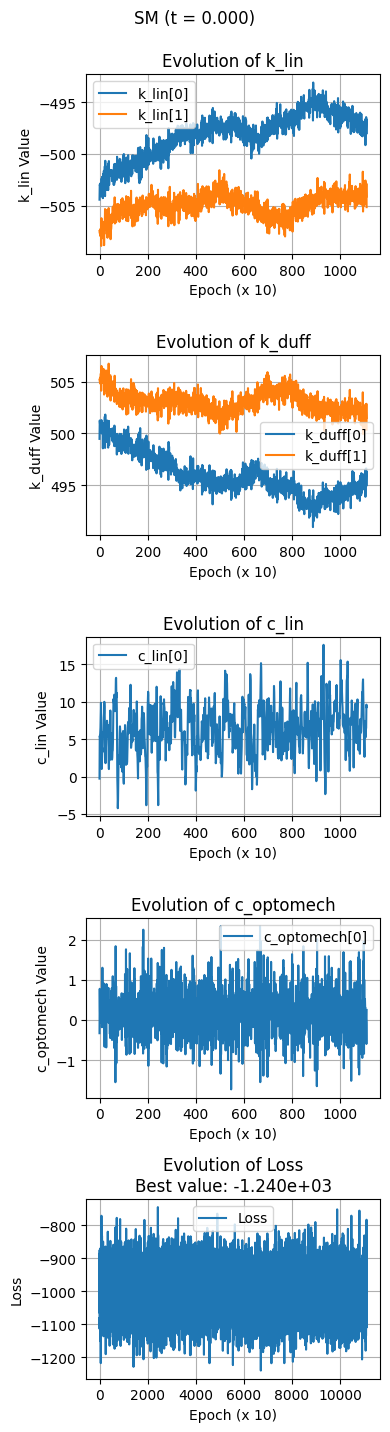

Optimization for time 1.184618730902688e-18
Epoch 0 - Loss: -1018.9838
Epoch 100 - Loss: -1016.1837
Epoch 200 - Loss: -1034.6778
Epoch 300 - Loss: -1003.9990
Epoch 400 - Loss: -1081.1055
Epoch 500 - Loss: -932.0425
Epoch 600 - Loss: -1008.4535
Epoch 700 - Loss: -1091.2124
Epoch 800 - Loss: -903.8420
Epoch 900 - Loss: -1016.4963
Epoch 1000 - Loss: -971.8507
Epoch 1100 - Loss: -1065.6868
Epoch 1200 - Loss: -962.5159
Epoch 1300 - Loss: -1034.4354
Epoch 1400 - Loss: -1050.3467
Epoch 1500 - Loss: -1043.7232
Epoch 1600 - Loss: -940.9632
Epoch 1700 - Loss: -1039.7809
Epoch 1800 - Loss: -1026.0036
Epoch 1900 - Loss: -953.3926
Epoch 2000 - Loss: -948.8274
Epoch 2100 - Loss: -979.8940
Epoch 2200 - Loss: -869.5605
Epoch 2300 - Loss: -1003.6162
Epoch 2400 - Loss: -970.9634
Epoch 2500 - Loss: -886.9384
Epoch 2600 - Loss: -1095.7655
Epoch 2700 - Loss: -1056.7231
Epoch 2800 - Loss: -959.1217
Epoch 2900 - Loss: -943.0694
Epoch 3000 - Loss: -1048.5325
Epoch 3100 - Loss: -924.7209
Epoch 3200 - Loss: -92

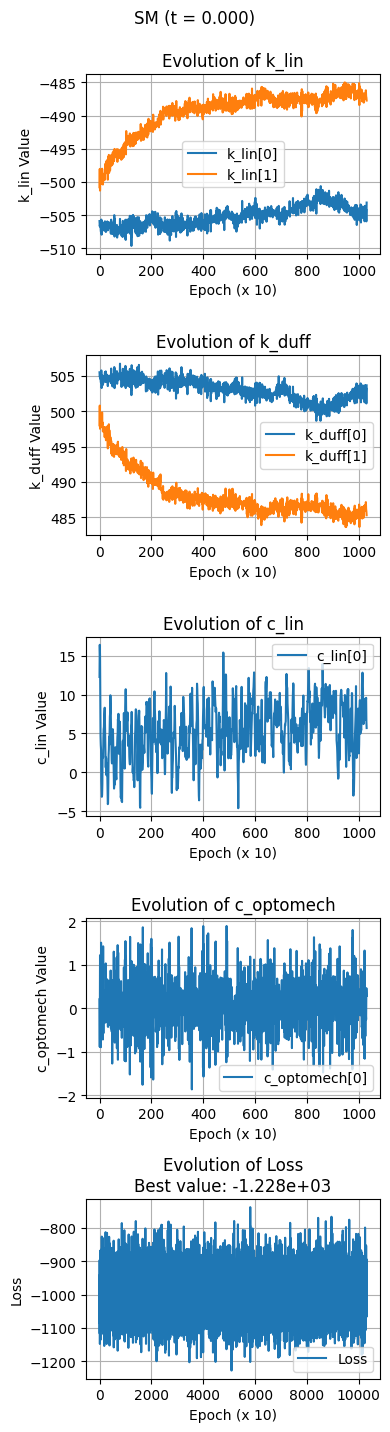

Optimization for time 5.526814857144616e-18
Epoch 0 - Loss: -1020.4136
Epoch 100 - Loss: -1073.8783
Epoch 200 - Loss: -978.2392
Epoch 300 - Loss: -987.2601
Epoch 400 - Loss: -991.4613
Epoch 500 - Loss: -941.9179
Epoch 600 - Loss: -951.5966
Epoch 700 - Loss: -1043.1251
Epoch 800 - Loss: -1003.0011
Epoch 900 - Loss: -1116.4326
Epoch 1000 - Loss: -1066.8392
Epoch 1100 - Loss: -1030.3376
Epoch 1200 - Loss: -989.5647
Epoch 1300 - Loss: -1020.6870
Epoch 1400 - Loss: -958.9624
Epoch 1500 - Loss: -1018.4171
Epoch 1600 - Loss: -911.1405
Epoch 1700 - Loss: -916.9399
Epoch 1800 - Loss: -919.5732
Epoch 1900 - Loss: -1069.6576
Epoch 2000 - Loss: -909.8992
Epoch 2100 - Loss: -935.5439
Epoch 2200 - Loss: -974.2631
Epoch 2300 - Loss: -937.2676
Epoch 2400 - Loss: -1119.3255
Epoch 2500 - Loss: -919.7709
Epoch 2600 - Loss: -1119.2875
Epoch 2700 - Loss: -1160.2139
Epoch 2800 - Loss: -925.5972
Epoch 2900 - Loss: -1073.7227
Epoch 3000 - Loss: -896.4260
Epoch 3100 - Loss: -990.8924
Epoch 3200 - Loss: -938.48

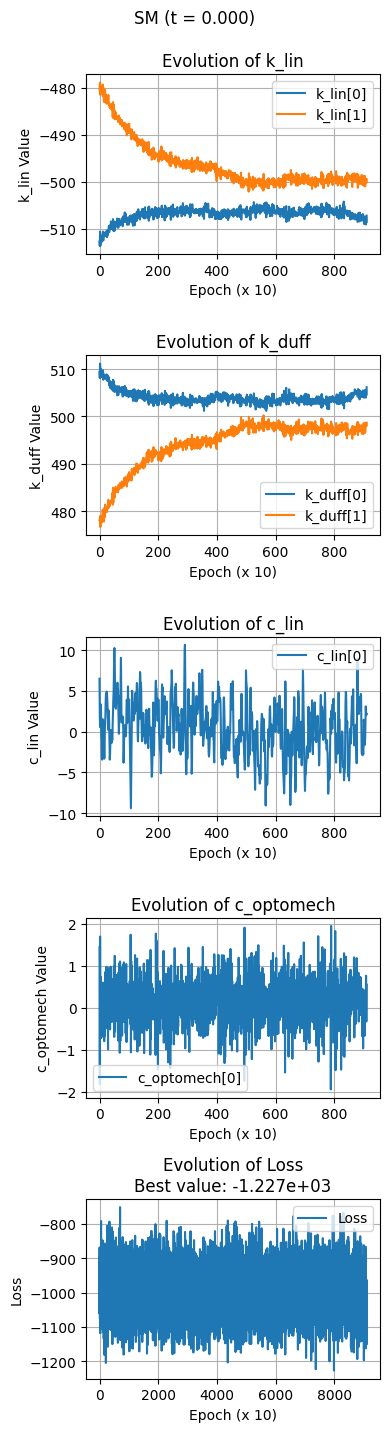

Optimization for time 2.5785243528842764e-17
Epoch 0 - Loss: -879.3295
Epoch 100 - Loss: -1032.7670
Epoch 200 - Loss: -935.2606
Epoch 300 - Loss: -991.1368
Epoch 400 - Loss: -1057.4635
Epoch 500 - Loss: -934.6216
Epoch 600 - Loss: -972.8729
Epoch 700 - Loss: -924.6814
Epoch 800 - Loss: -1135.3283
Epoch 900 - Loss: -1123.3679
Epoch 1000 - Loss: -1012.0899
Epoch 1100 - Loss: -1069.4384
Epoch 1200 - Loss: -941.5985
Epoch 1300 - Loss: -912.3992
Epoch 1400 - Loss: -1037.7990
Epoch 1500 - Loss: -1143.3388
Epoch 1600 - Loss: -1050.6359
Epoch 1700 - Loss: -983.6876
Epoch 1800 - Loss: -1201.4611
Epoch 1900 - Loss: -1052.0732
Epoch 2000 - Loss: -1128.3679
Epoch 2100 - Loss: -1085.4453
Epoch 2200 - Loss: -901.7692
Epoch 2300 - Loss: -992.3967
Epoch 2400 - Loss: -978.9191
Epoch 2500 - Loss: -993.7101
Epoch 2600 - Loss: -976.6813
Epoch 2700 - Loss: -1082.4734
Epoch 2800 - Loss: -1108.5404
Epoch 2900 - Loss: -1047.5341
Epoch 3000 - Loss: -1087.1070
Epoch 3100 - Loss: -917.1172
Epoch 3200 - Loss: -10

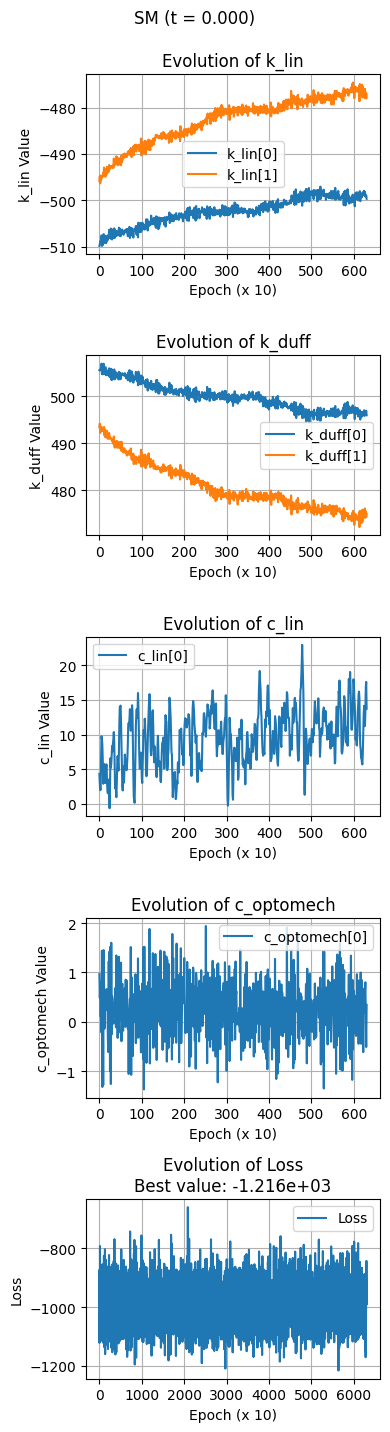

Optimization for time 1.2030053494233237e-16
Epoch 0 - Loss: -1040.2874
Epoch 100 - Loss: -936.3020
Epoch 200 - Loss: -897.6922
Epoch 300 - Loss: -1036.0464
Epoch 400 - Loss: -973.0347
Epoch 500 - Loss: -1050.2489
Epoch 600 - Loss: -1089.3732
Epoch 700 - Loss: -972.9780
Epoch 800 - Loss: -1062.7059
Epoch 900 - Loss: -971.5382
Epoch 1000 - Loss: -1071.5448
Epoch 1100 - Loss: -1076.1707
Epoch 1200 - Loss: -1098.5842
Epoch 1300 - Loss: -953.5698
Epoch 1400 - Loss: -1073.8222
Epoch 1500 - Loss: -1087.5463
Epoch 1600 - Loss: -987.9844
Epoch 1700 - Loss: -1088.0153
Epoch 1800 - Loss: -1032.7641
Epoch 1900 - Loss: -1016.8572
Epoch 2000 - Loss: -968.3950
Epoch 2100 - Loss: -1006.4726
Epoch 2200 - Loss: -1082.6933
Epoch 2300 - Loss: -1016.4236
Epoch 2400 - Loss: -1070.7720
Epoch 2500 - Loss: -979.8183
Epoch 2600 - Loss: -1010.2729
Epoch 2700 - Loss: -1019.5119
Epoch 2800 - Loss: -971.4926
Epoch 2900 - Loss: -904.4362
Epoch 3000 - Loss: -1058.4746
Epoch 3100 - Loss: -963.7624
Epoch 3200 - Loss: 

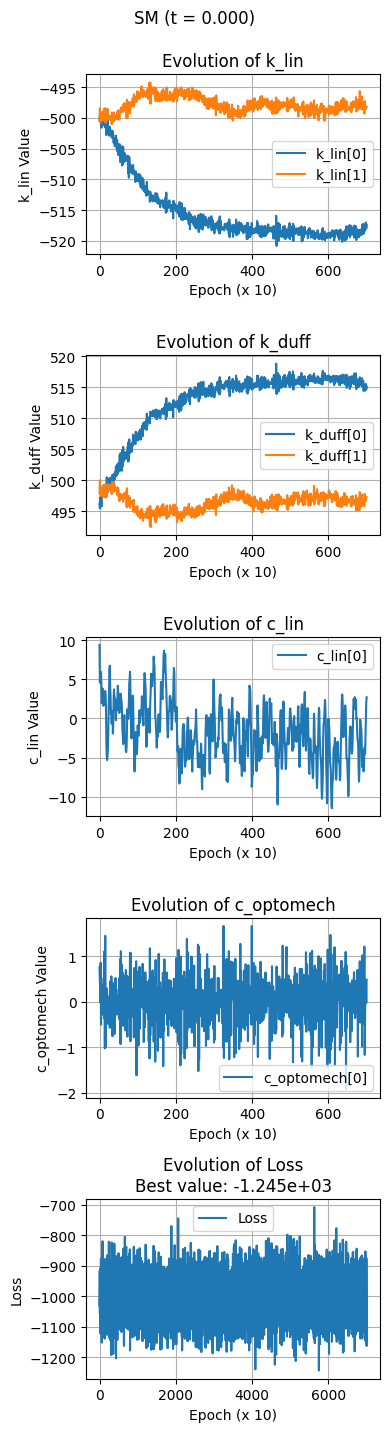

Optimization for time 5.612597255954962e-16
Epoch 0 - Loss: -1103.1689
Epoch 100 - Loss: -1115.9965
Epoch 200 - Loss: -1110.2086
Epoch 300 - Loss: -1116.2238
Epoch 400 - Loss: -1062.7889
Epoch 500 - Loss: -1103.2260
Epoch 600 - Loss: -1109.6386
Epoch 700 - Loss: -1033.7221
Epoch 800 - Loss: -1030.7412
Epoch 900 - Loss: -950.3511
Epoch 1000 - Loss: -981.3799
Epoch 1100 - Loss: -1083.0775
Epoch 1200 - Loss: -995.3309
Epoch 1300 - Loss: -1052.8619
Epoch 1400 - Loss: -825.2084
Epoch 1500 - Loss: -1143.2516
Epoch 1600 - Loss: -925.2341
Epoch 1700 - Loss: -1099.5382
Epoch 1800 - Loss: -1011.2653
Epoch 1900 - Loss: -1003.4202
Epoch 2000 - Loss: -1072.7246
Epoch 2100 - Loss: -1083.0794
Epoch 2200 - Loss: -1078.4601
Epoch 2300 - Loss: -1048.0672
Epoch 2400 - Loss: -1059.7989
Epoch 2500 - Loss: -875.4880
Epoch 2600 - Loss: -982.5832
Epoch 2700 - Loss: -964.0428
Epoch 2800 - Loss: -967.2938
Epoch 2900 - Loss: -1121.5892
Epoch 3000 - Loss: -950.9721
Epoch 3100 - Loss: -1118.8890
Epoch 3200 - Loss:

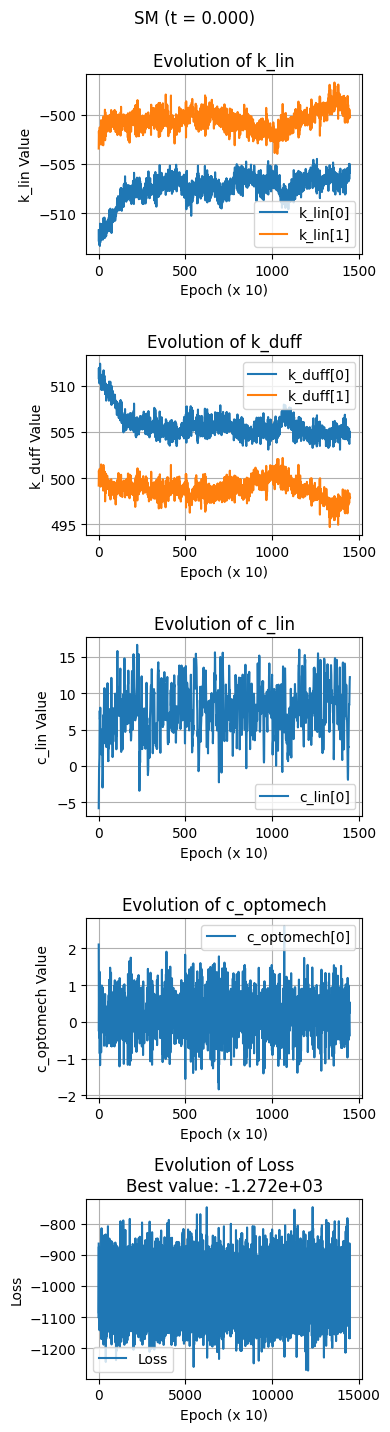

Optimization for time 2.618545958474243e-15
Epoch 0 - Loss: -1000.1899
Epoch 100 - Loss: -1050.2039
Epoch 200 - Loss: -961.0550
Epoch 300 - Loss: -1030.1038
Epoch 400 - Loss: -973.0220
Epoch 500 - Loss: -1048.9612
Epoch 600 - Loss: -984.8860
Epoch 700 - Loss: -984.4489
Epoch 800 - Loss: -1021.2803
Epoch 900 - Loss: -1037.2311
Epoch 1000 - Loss: -1125.7888
Epoch 1100 - Loss: -1122.7115
Epoch 1200 - Loss: -1008.0046
Epoch 1300 - Loss: -902.2729
Epoch 1400 - Loss: -946.1089
Epoch 1500 - Loss: -957.6416
Epoch 1600 - Loss: -1095.4973
Epoch 1700 - Loss: -899.8365
Epoch 1800 - Loss: -891.5850
Epoch 1900 - Loss: -1081.7375
Epoch 2000 - Loss: -966.6297
Epoch 2100 - Loss: -1079.4568
Epoch 2200 - Loss: -1100.8407
Epoch 2300 - Loss: -1056.9300
Epoch 2400 - Loss: -1098.7711
Epoch 2500 - Loss: -1005.6453
Epoch 2600 - Loss: -977.1347
Epoch 2700 - Loss: -1031.6533
Epoch 2800 - Loss: -1049.2117
Epoch 2900 - Loss: -1043.3915
Epoch 3000 - Loss: -895.7309
Epoch 3100 - Loss: -858.1470
Epoch 3200 - Loss: -1

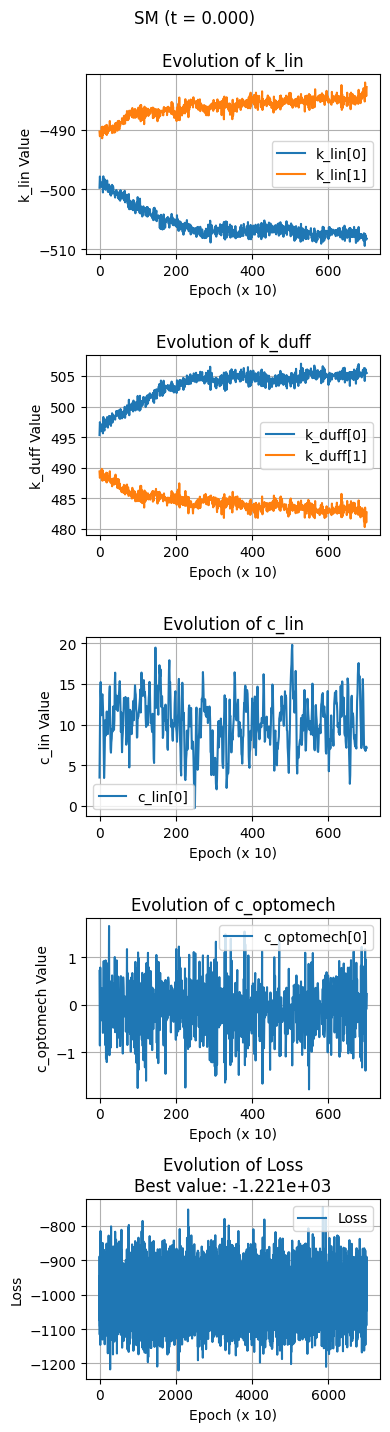

Optimization for time 1.2216773489967951e-14
Epoch 0 - Loss: -937.8617
Epoch 100 - Loss: -1058.3902
Epoch 200 - Loss: -966.8557
Epoch 300 - Loss: -1030.0034
Epoch 400 - Loss: -1140.9689
Epoch 500 - Loss: -1082.4622
Epoch 600 - Loss: -956.4615
Epoch 700 - Loss: -1008.4494
Epoch 800 - Loss: -1086.5763
Epoch 900 - Loss: -974.1981
Epoch 1000 - Loss: -1012.8428
Epoch 1100 - Loss: -1012.9502
Epoch 1200 - Loss: -1090.1954
Epoch 1300 - Loss: -978.6439
Epoch 1400 - Loss: -1054.1721
Epoch 1500 - Loss: -1064.8787
Epoch 1600 - Loss: -921.4169
Epoch 1700 - Loss: -987.4548
Epoch 1800 - Loss: -1004.9741
Epoch 1900 - Loss: -1038.0860
Epoch 2000 - Loss: -1145.2754
Epoch 2100 - Loss: -1015.8164
Epoch 2200 - Loss: -1071.2784
Epoch 2300 - Loss: -1034.5434
Epoch 2400 - Loss: -990.3842
Epoch 2500 - Loss: -1005.8581
Epoch 2600 - Loss: -1046.2299
Epoch 2700 - Loss: -974.8219
Epoch 2800 - Loss: -1020.5451
Epoch 2900 - Loss: -906.5686
Epoch 3000 - Loss: -1063.3574
Epoch 3100 - Loss: -1024.4784
Epoch 3200 - Loss

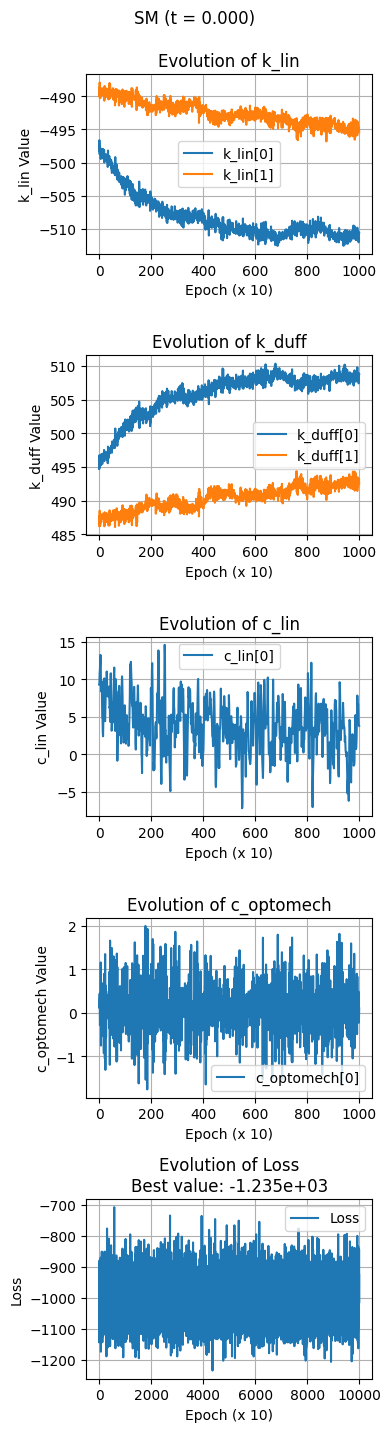

Optimization for time 5.699711094326062e-14
Epoch 0 - Loss: -1068.9711
Epoch 100 - Loss: -1016.0156
Epoch 200 - Loss: -1012.4846
Epoch 300 - Loss: -959.7577
Epoch 400 - Loss: -1053.6359
Epoch 500 - Loss: -1093.8424
Epoch 600 - Loss: -877.8393
Epoch 700 - Loss: -1037.7847
Epoch 800 - Loss: -1015.9301
Epoch 900 - Loss: -913.2664
Epoch 1000 - Loss: -911.2837
Epoch 1100 - Loss: -1014.3466
Epoch 1200 - Loss: -1083.3708
Epoch 1300 - Loss: -914.4090
Epoch 1400 - Loss: -977.6523
Epoch 1500 - Loss: -1048.6608
Epoch 1600 - Loss: -1036.4548
Epoch 1700 - Loss: -918.2707
Epoch 1800 - Loss: -884.5613
Epoch 1900 - Loss: -1063.8167
Epoch 2000 - Loss: -933.2177
Epoch 2100 - Loss: -1055.1794
Epoch 2200 - Loss: -939.1401
Epoch 2300 - Loss: -1009.4469
Epoch 2400 - Loss: -908.9607
Epoch 2500 - Loss: -1046.5212
Epoch 2600 - Loss: -999.3969
Epoch 2700 - Loss: -1061.1969
Epoch 2800 - Loss: -984.7328
Epoch 2900 - Loss: -1067.4980
Epoch 3000 - Loss: -1028.2335
Epoch 3100 - Loss: -1032.5676
Epoch 3200 - Loss: -1

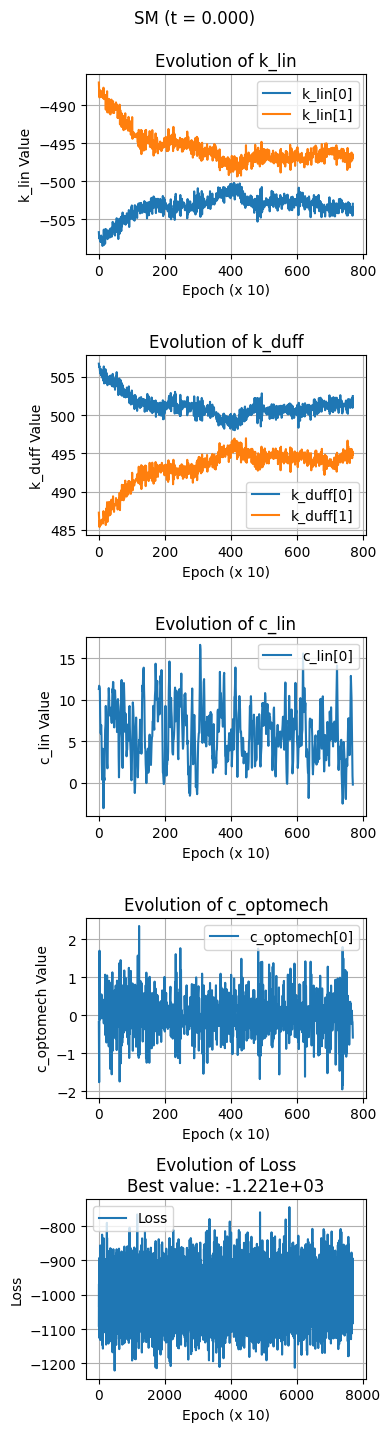

Optimization for time 2.6591887445126936e-13
Epoch 0 - Loss: -948.4737
Epoch 100 - Loss: -1070.9957
Epoch 200 - Loss: -877.5613
Epoch 300 - Loss: -1144.1532
Epoch 400 - Loss: -987.9533
Epoch 500 - Loss: -985.8029
Epoch 600 - Loss: -1010.6076
Epoch 700 - Loss: -1212.9805
Epoch 800 - Loss: -1050.8821
Epoch 900 - Loss: -952.0081
Epoch 1000 - Loss: -966.6466
Epoch 1100 - Loss: -1079.6771
Epoch 1200 - Loss: -972.2694
Epoch 1300 - Loss: -943.7499
Epoch 1400 - Loss: -1072.5281
Epoch 1500 - Loss: -1043.3079
Epoch 1600 - Loss: -923.0511
Epoch 1700 - Loss: -1003.9730
Epoch 1800 - Loss: -928.1351
Epoch 1900 - Loss: -943.8732
Epoch 2000 - Loss: -1103.1027
Epoch 2100 - Loss: -974.1967
Epoch 2200 - Loss: -955.9608
Epoch 2300 - Loss: -1116.1865
Epoch 2400 - Loss: -1086.5284
Epoch 2500 - Loss: -1037.6802
Epoch 2600 - Loss: -1052.8851
Epoch 2700 - Loss: -1004.2622
Epoch 2800 - Loss: -1079.3884
Epoch 2900 - Loss: -1008.4826
Epoch 3000 - Loss: -1031.6336
Epoch 3100 - Loss: -1131.7280
Epoch 3200 - Loss: -

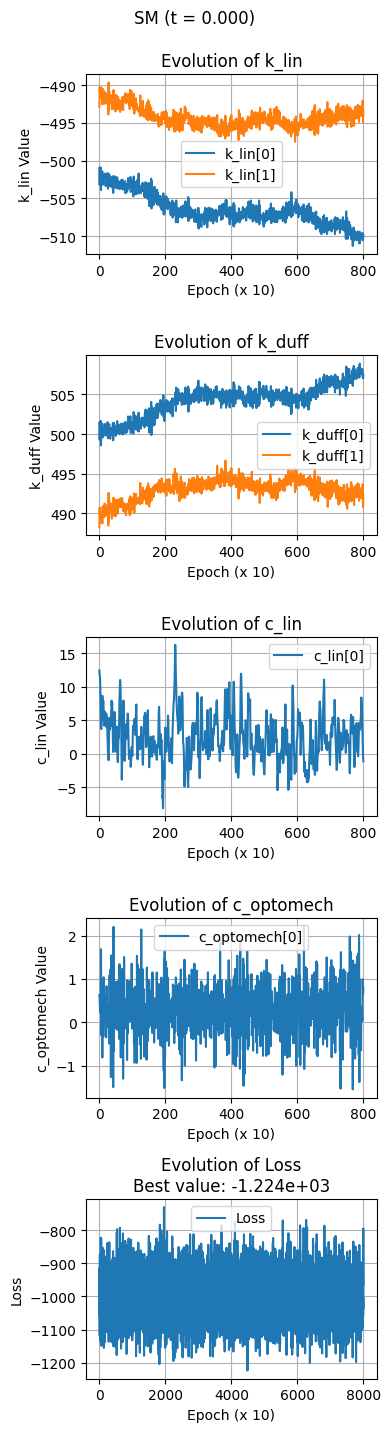

Optimization for time 1.24063915905883e-12
Epoch 0 - Loss: -1029.4979
Epoch 100 - Loss: -973.5624
Epoch 200 - Loss: -1125.8009
Epoch 300 - Loss: -1126.7070
Epoch 400 - Loss: -1009.4759
Epoch 500 - Loss: -951.4743
Epoch 600 - Loss: -1118.6823
Epoch 700 - Loss: -968.1956
Epoch 800 - Loss: -876.9900
Epoch 900 - Loss: -1049.5802
Epoch 1000 - Loss: -1033.8733
Epoch 1100 - Loss: -1057.5520
Epoch 1200 - Loss: -984.1430
Epoch 1300 - Loss: -991.0037
Epoch 1400 - Loss: -997.7799
Epoch 1500 - Loss: -1100.8703
Epoch 1600 - Loss: -930.1174
Epoch 1700 - Loss: -1064.4119
Epoch 1800 - Loss: -966.5753
Epoch 1900 - Loss: -1022.0193
Epoch 2000 - Loss: -1092.5486
Epoch 2100 - Loss: -1081.8172
Epoch 2200 - Loss: -993.1809
Epoch 2300 - Loss: -992.1022
Epoch 2400 - Loss: -1003.9674
Epoch 2500 - Loss: -1090.2583
Epoch 2600 - Loss: -1048.4152
Epoch 2700 - Loss: -1089.9231
Epoch 2800 - Loss: -1060.9613
Epoch 2900 - Loss: -907.3049
Epoch 3000 - Loss: -1089.5486
Epoch 3100 - Loss: -977.9335
Epoch 3200 - Loss: -11

In [ ]:
load_param_histories = False

if load_param_histories:
    # Load existing parameters
    params_history_all_t = jnp.load(f"{output_dir}/params_history.npy")
else:
    # Setup optimization parameters
    mask = jnp.ones(params_flattened_initial.shape[0])
    # mask = mask.at[0].set(1.)
    # mask = mask.at[1].set(1.)
    # mask = mask.at[-1].set(0.0)
    

    # Plotting parameters
    plot_steps = True  # Flag to control whether to plot during optimization
    plot_slice = 10     # Plot every nth step


    # Initialize storage for parameters at each time step
    params_history_all_t = []
    current_params = params_flattened_initial

    # Loop over time points
    for t_idx, t_curr in enumerate(forward_time_pts):
        print(f"Optimization for time {t_curr}")
        
        # Generate samples at current time
        key, subkey = jr.split(key)
        samples_t = sample_forward_process(
            t_curr, n_samples, D=1, sigma_final=sigma_forward, samples0=samples_0, key=subkey
        )
        
        # Perform optimization starting from previous best parameters
        key, subkey = jr.split(key)
        
        params_history, loss_history = run_optimization(
            loss_fn_per_batch=loss_fn_per_batch,
            params_initial=current_params,
            samples=samples_t,
            mask=mask,
            gradient_fn_per_batch=gradient_fn_per_batch,
            key=subkey,
            batch_size=batch_size,
            learning_rate=learning_rate,
            n_epochs=n_epochs,
            maximize=maximize,
            window_size=window_size,
            tolerance=tolerance,
            patience=patience
        )
        
        _, current_params, _ = get_best_params(params_history, loss_history, maximize=maximize)
        
        params_history_all_t.append(current_params)
        
        if plot_steps:
            if t_idx % plot_slice == 0:
                # Plot optimization progress
                plot_parameter_evolution(
                    params_history=params_history,
                    loss_history=loss_history,
                    time = t_curr,
                    time_index = t_idx,
                    unflatten=unflatten,
                    N_osc=N_osc,
                    slicing=10,
                    title=f"{training_method} (t = {t_curr:.3f})",
                    maximize=maximize,
                    labels_on=True,
                    save_fig=True,
                    path=output_dir,
                    param_names=params_names
                )
            
    # Convert params_history_all_t to array for easier analysis
    params_history_all_t = jnp.array(params_history_all_t)
    jnp.save(f"{output_dir}/params_history.npy", params_history_all_t)


### Smoothen and interpolate parameter evolution

In [ ]:
use_smoothed_params = False
if use_smoothed_params:
    # First smooth the parameters
    smoothed_params = smooth_parameters(params_history_all_t, window_lengths = [31, 31, 31, 31, 31, 31], poly_orders = [3, 3, 3, 3, 3, 3])
    # Get interpolator function
    params_interpolator = interpolate_parameters(smoothed_params, forward_time_pts)
else:
    # Get interpolator function
    params_interpolator = interpolate_parameters(params_history_all_t, forward_time_pts)

# Then interpolate the smoothed parameters
time_eval = jnp.linspace(forward_time_pts[0],forward_time_pts[-1],200)
# interpolated_params = interpolate_parameters(smoothed_params, forward_time_pts, time_dense)
interpolated_params = params_interpolator(time_eval)

# Create figure
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Parameter Evolution Over Time: Raw and Interpolated', fontsize=16)

# Plot settings
param_names = ['k_lin', 'k_duff', 'c_lin', 'c_optomech']
axes = [ax1, ax2, ax3, ax4]
colors = ['b', 'r', 'g', 'm']
param_indices = [(0,1), (2,3), (4,), (5,)]

# Plot for each parameter type
for ax, param_name, color, indices in zip(axes, param_names, colors, param_indices):
    for idx, style in zip(indices, ['-', '--']):
        # Plot raw data
        ax.plot(forward_time_pts, params_history_all_t[:, idx], color + style, alpha=0.3, 
                label=f'{param_name}[{idx}] (from optimization)')
        
        # Plot interpolated data
        ax.plot(time_eval, interpolated_params[:, idx], color + style, linewidth=2,
                label=f'{param_name}[{idx}] (interpolated)')
    
    ax.set_title(f'{param_name} Evolution')
    ax.set_xlabel('Time')
    ax.set_ylabel('Value')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

### Run reverse SDE:

In [15]:
forward_params = jnp.zeros_like(params_flattened_initial)
forward_params = forward_params.at[0].set(1.)
forward_params = forward_params.at[1].set(1.)
params_interpolator_reverse_plus_linear = lambda t: 2*params_interpolator(t_forward - t) - 1/sigma_forward**2 * forward_params

In [ ]:
# Create time points for evaluation
time_eval = jnp.linspace(0, t_forward, 200)

# Get parameters at each time point
params_over_time = jnp.vstack([params_interpolator_reverse_plus_linear(t) for t in time_eval])

# Create figure
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Parameter Evolution Over Time: Reverse Plus Linear', fontsize=16)

# Plot settings
param_names = ['k_lin', 'k_duff', 'c_lin', 'c_optomech']
axes = [ax1, ax2, ax3, ax4]
colors = ['b', 'r', 'g', 'm']
param_indices = [(0,1), (2,3), (4,), (5,)]

# Plot for each parameter type
for ax, param_name, color, indices in zip(axes, param_names, colors, param_indices):
    for idx, style in zip(indices, ['-', '--']):
        ax.plot(time_eval, params_over_time[:, idx], color + style, linewidth=2,
                label=f'{param_name}[{idx}]')
    
    ax.set_title(f'{param_name} Evolution')
    ax.set_xlabel('Time')
    ax.set_ylabel('Value')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

In [17]:
# Setup SDE functions
drift_fn, diffusion_fn = setup_overdamped_SDE(energy_fn, params_interpolator_reverse_plus_linear, N_osc, time_dependent_parms=True)

In [ ]:
# Assuming drift_fn is already defined and takes (time, state, args) as input
# Define the range for x1 and x2
x_range = jnp.linspace(-1, 1, 100)  # Example range from -5 to 5

# Define filename for saving/loading parameters
n_time_steps = 5
# forward_time_pts = jnp.linspace(0., t_forward, n_time_steps)
time_steps = t_forward - jnp.exp(jnp.linspace(jnp.log(t_forward), jnp.log(1e-6), n_time_steps))


# Plot drift as a function of x1 for x2 = 0
plt.figure(figsize=(12, 6))
for t in time_steps:
    drift_x1 = [drift_fn(t, jnp.array([x1, 0]), args=())[0] for x1 in x_range]
    plt.plot(x_range, drift_x1, label=f'Drift at x2 = 0, t = {t:.1f}')

plt.xlabel('x1')
plt.ylabel('Drift')
plt.title('Drift as a function of x1 for x2 = 0')
plt.legend()
plt.grid(True)
plt.show()

# Plot drift as a function of x2 for x1 = 0
plt.figure(figsize=(12, 6))
for t in time_steps:
    drift_x2 = [drift_fn(t, jnp.array([0, x2]), args=())[1] for x2 in x_range]
    plt.plot(x_range, drift_x2, label=f'Drift at x1 = 0, t = {t:.1f}')

plt.xlabel('x2')
plt.ylabel('Drift')
plt.title('Drift as a function of x2 for x1 = 0')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
t0 = 0.0
t1 = t_forward
ts = jnp.linspace(t0, t1, 10)
dt0 = ts[1] - ts[0]

# Generate multiple initial states
# n_trajectories = 2000
# key, subkey = jr.split(key)
# initial_states = sample_forward_process(t_forward, n_trajectories, D=1, samples0=samples_0, key=subkey, diffusion_rate=diffusion_rate)
# Sample initial conditions from N(0, I)
n_trajectories = 1000  # or any other number of trajectories you need
n_dimensions = 2  # assuming 2D, adjust as necessary
key, subkey = jr.split(key)
initial_states = jr.normal(subkey, (n_trajectories, n_dimensions))

# Generate a key for each initial condition
key, subkey = jr.split(key)
keys_brownian = jr.split(subkey, n_trajectories)

# Vectorize solve_SDE across both initial states and keys
vectorized_solve_SDE = vmap(
    lambda init_state, key_b: solve_SDE(
        drift_fn, 
        diffusion_fn, 
        init_state,
        key_b, 
        t0, 
        t1, 
        ts.shape[0], 
        dt0
    ),
    in_axes=(0, 0)
)


# Run SDE for all initial states at once
solutions = vectorized_solve_SDE(initial_states, keys_brownian)
all_trajectories = solutions.ys  # Shape: (n_trajectories, n_timesteps, 2)
final_states = all_trajectories[:, -1, :]  # Shape: (n_trajectories, 2)


In [ ]:
solve_time = 0.0
drift_fn, diffusion_fn = setup_overdamped_SDE(energy_fn, params_interpolator(solve_time), N_osc,time_dependent_parms=False)
t0 = 0.0
t1 = 10 
ts = jnp.linspace(t0, t1, 1000)
dt0 = ts[1] - ts[0]
initial_state = jnp.array([-.0,0.])
key_equilibrium = jr.PRNGKey(111111)
solution_direct = solve_SDE(drift_fn, diffusion_fn, initial_state,key_equilibrium, t0, t1, ts.shape[0], dt0)
sde_samples_direct = solution_direct.ys


In [ ]:
param_list = [params_interpolator(solve_time)]
titles = ["Solution from reverse process"]
plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=final_states,
    sample_stride=1,
    x1_range=(-1.5, 1.5),    
    x2_range=(-1.5, 1.5),    
    n_points=50,    
    titles=titles,       
    figsize=None,    
    fontsize=12,         
    suptitle="Energy landscape with samples from reverse process"  
)

In [ ]:
param_list = [params_interpolator(solve_time)]
titles = ["Solution from direct integration"]
plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=sde_samples_direct,
    sample_stride=1,
    x1_range=(-1.5, 1.5),    
    x2_range=(-1.5, 1.5),    
    n_points=50,    
    titles=titles,       
    figsize=None,    
    fontsize=12,         
    suptitle="Energy landscape with samples from direct integration"  
)

In [ ]:
# Set font sizes
SMALL_SIZE = 16
MEDIUM_SIZE = 18
BIGGER_SIZE = 22

# Create 2x2 subplot
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Final States vs Equilibrium Sampling Distributions', fontsize=BIGGER_SIZE)

# Top row: Initial and Final states
ax1.hist(initial_states[:, 0], bins=30, alpha=0.5, density=True, label='Initial', color='blue')
ax1.hist(final_states[:, 0], bins=30, alpha=0.5, density=True, label='Final', color='red')
ax2.hist(initial_states[:, 1], bins=30, alpha=0.5, density=True, label='Initial', color='blue')
ax2.hist(final_states[:, 1], bins=30, alpha=0.5, density=True, label='Final', color='red')

# Bottom row: Equilibrium sampling in green
ax3.hist(sde_samples_direct[:, 0], bins=30, alpha=0.5, density=True, label='Equilibrium sampling', color='green')
ax4.hist(sde_samples_direct[:, 1], bins=30, alpha=0.5, density=True, label='Equilibrium sampling', color='green')

# Add exact marginal Gaussians to all plots
x = jnp.linspace(-1.5, 1.5, 1000)

# Plot marginals for each subplot separately with correct dimension
for ax, dim in [(ax1, 0), (ax2, 1), (ax3, 0), (ax4, 1)]:
    marginal = jnp.zeros_like(x)
    for w, m, c in zip(weights, means, covs):
        mean = m[dim]
        std = jnp.sqrt(c[dim, dim])
        marginal += w * jnp.exp(-0.5 * ((x - mean) / std) ** 2) / (std * jnp.sqrt(2 * jnp.pi))
    ax.plot(x, marginal, '--k', linewidth=2, label=f'Target marginal {["X1", "X2"][dim]}')
    
    # Increase font sizes for tick labels
    ax.tick_params(axis='both', which='major', labelsize=SMALL_SIZE)

# Set titles and labels with increased font sizes
ax1.set_title('Initial and Final X1 Distribution', fontsize=MEDIUM_SIZE)
ax1.set_xlabel('X1', fontsize=MEDIUM_SIZE)
ax1.set_ylabel('Density', fontsize=MEDIUM_SIZE)
ax1.legend(fontsize=SMALL_SIZE)

ax2.set_title('Initial and Final X2 Distribution', fontsize=MEDIUM_SIZE)
ax2.set_xlabel('X2', fontsize=MEDIUM_SIZE)
ax2.set_ylabel('Density', fontsize=MEDIUM_SIZE)
ax2.legend(fontsize=SMALL_SIZE)

ax3.set_title('Equilibrium Sampling X1', fontsize=MEDIUM_SIZE)
ax3.set_xlabel('X1', fontsize=MEDIUM_SIZE)
ax3.set_ylabel('Density', fontsize=MEDIUM_SIZE)
ax3.legend(fontsize=SMALL_SIZE)

ax4.set_title('Equilibrium Sampling X2', fontsize=MEDIUM_SIZE)
ax4.set_xlabel('X2', fontsize=MEDIUM_SIZE)
ax4.set_ylabel('Density', fontsize=MEDIUM_SIZE)
ax4.legend(fontsize=SMALL_SIZE)

plt.tight_layout()
plt.show()